# Baseline forward solve: ultrasound over the Shepp-Logan phantom

For this run, we will use a source frequency of 185kHz. At a minimum wave speed of $1450 ms^{-1}$ (water background), the maximum wavelength we should observe is 

$$\lambda_\text{max} = \frac 1450 {185000} = 0.00784 m.$$

If we require say 6 points per wavelength then we require $dx = \frac {\lambda_\text{min}} {6} = 0.00131m$. Then for a domain of length $20cm$ we want $nx = 0.20/0.00131 = 153$. Let's set this up.

In [2]:
from odil_wave import Grid, SheppLoganModel, Sources, Wavefield, WaveEquation, Problem, ForwardLoss, GaussNewtonOptimiser

In [3]:
grid = Grid(nx=160, ny=160, xmax=0.2, ymax=0.2, c_min=1430.0, c_max=1580.0, cfl_safety=0.9)
print(grid.summary)

Nx, Ny, Nt: 160, 160, 470
dx, dy, dt: 0.001257862m, 0.001257862m, 0.000000506s
CFL (at c_max = 1580.0):  0.899
x in [0.000, 0.200]m
y in [0.000, 0.200]m


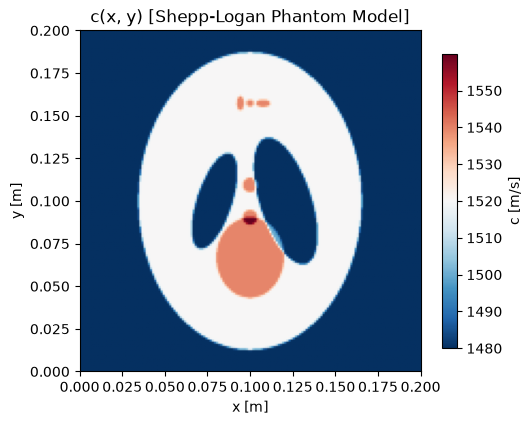

In [4]:
model = SheppLoganModel(grid, contrast=200, background_c=1480.0, interior_fill=0.95, mask_skull=True)
_ = model.show()

In [8]:
source = Sources(grid, n_sources=1, source_locs=((0.015, 0.1),), f0=185000)

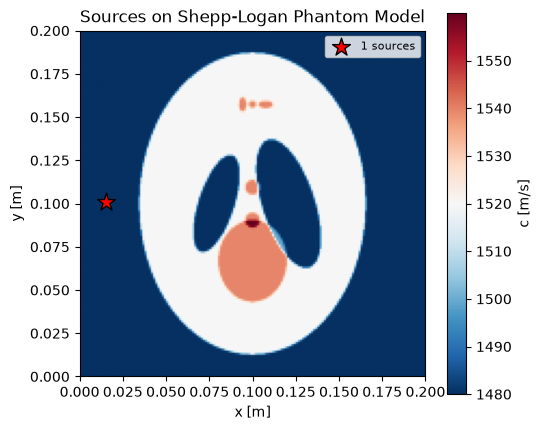

In [9]:
_ = source.show(model)

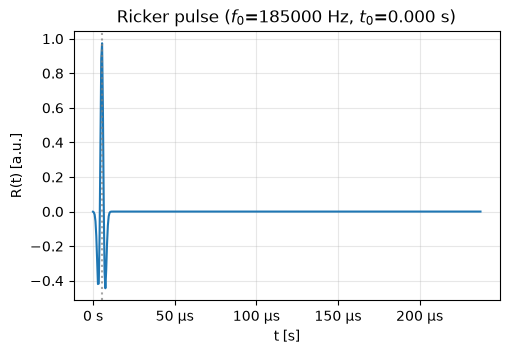

In [10]:
_ = source.plot_source_pulse()

In [7]:
wavefield = Wavefield(grid)

In [9]:
equation = WaveEquation(wavefield, model, time_order=2, space_order=8)

In [10]:
problem = Problem(equation, source)

In [11]:
loss = ForwardLoss(problem)

In [12]:
optimiser = GaussNewtonOptimiser(loss)

In [ ]:
result = optimiser.minimise(wavefield, method="paradiag", alpha=1e-3)

In [ ]:
result.exit_reason

In [ ]:
result.solution.animate(title="300kHz source over soft Shepp Logan Phantom")